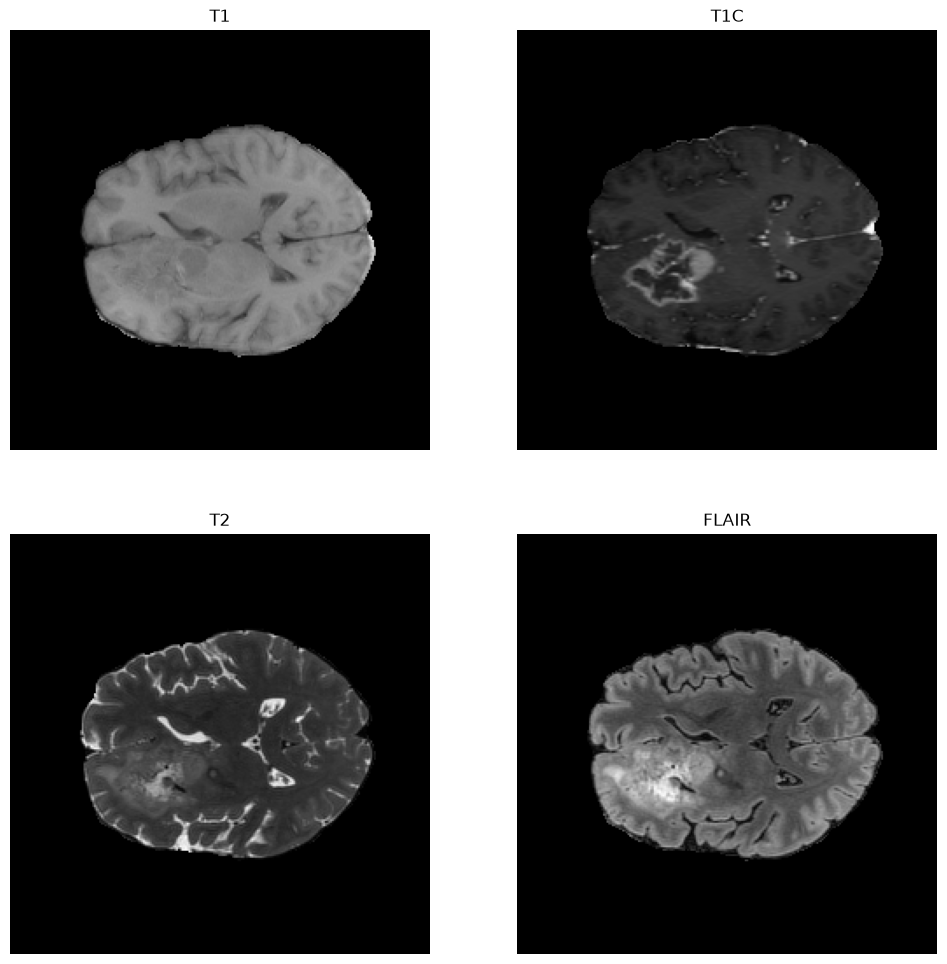

In [8]:
import os
import nibabel as nib
import matplotlib.pyplot as plt

patient_folder = r"C:\Users\Admin\Desktop\DL project\Brain Tumor Data\BraTS-GLI-00000-000"

modalities = {
    "T1": "BraTS-GLI-00000-000-t1n.nii.gz",
    "T1C": "BraTS-GLI-00000-000-t1c.nii.gz",
    "T2": "BraTS-GLI-00000-000-t2w.nii.gz",
    "FLAIR": "BraTS-GLI-00000-000-t2f.nii.gz"
}

plt.figure(figsize=(12,12))

for i, (title, filename) in enumerate(modalities.items(), start=1):
    img = nib.load(os.path.join(patient_folder, filename)).get_fdata()
    slice_number = img.shape[2] // 2

    plt.subplot(2,2,i)
    plt.imshow(img[:, :, slice_number], cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.show()

Tumor found in slice: 49


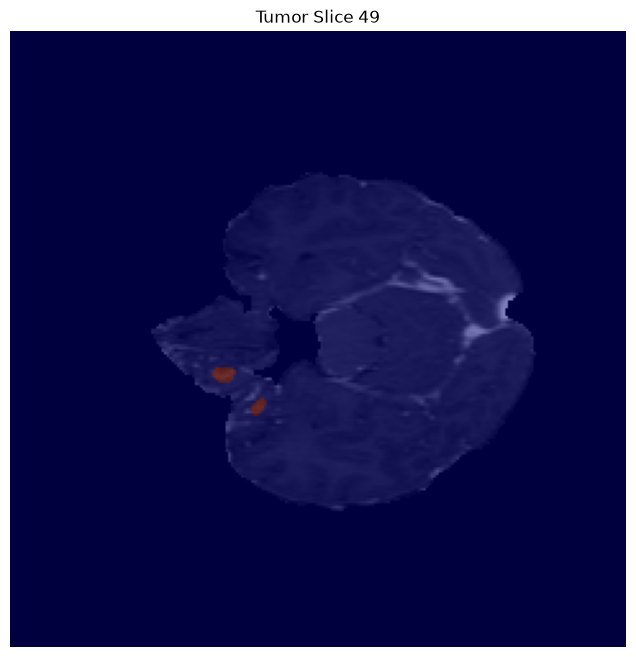

In [9]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# Patient folder
patient_folder = r"C:\Users\Admin\Desktop\DL project\Brain Tumor Data\BraTS-GLI-00000-000"

# Load MRI and Mask
image = nib.load(os.path.join(patient_folder, "BraTS-GLI-00000-000-t1c.nii.gz")).get_fdata()
mask = nib.load(os.path.join(patient_folder, "BraTS-GLI-00000-000-seg.nii.gz")).get_fdata()

# Find a slice that contains tumor
slice_no = None

for i in range(mask.shape[2]):
    if np.max(mask[:, :, i]) > 0:
        slice_no = i
        break

print("Tumor found in slice:", slice_no)

# Show MRI + Mask Overlay
plt.figure(figsize=(8,8))

plt.imshow(image[:, :, slice_no], cmap="gray")
plt.imshow(mask[:, :, slice_no], cmap="jet", alpha=0.5)

plt.title(f"Tumor Slice {slice_no}")
plt.axis("off")

plt.show()

In [10]:
from pathlib import Path

# Path to your 50-patient dataset
dataset_path = Path(r"C:\Users\Admin\Desktop\DL project\Practice 50 Data")

# Get all patient folders
patient_folders = sorted([p for p in dataset_path.iterdir() if p.is_dir()])

print(f"Total Patients: {len(patient_folders)}")

# Show first 5 patients
for patient in patient_folders[:5]:
    print(patient.name)

Total Patients: 48
BraTS-GLI-00000-000
BraTS-GLI-00002-000
BraTS-GLI-00003-000
BraTS-GLI-00005-000
BraTS-GLI-00006-000


In [13]:
import nibabel as nib

for patient in patient_folders:
    # Load MRI
    # Load Mask
    # Remove empty slices
    # Normalize
    # Resize
    patient = patient_folders[0]
    
    patient_id = patient.name
    
    t1 = nib.load(patient / f"{patient_id}-t1n.nii.gz").get_fdata()
    t1ce = nib.load(patient / f"{patient_id}-t1c.nii.gz").get_fdata()
    t2 = nib.load(patient / f"{patient_id}-t2w.nii.gz").get_fdata()
    flair = nib.load(patient / f"{patient_id}-t2f.nii.gz").get_fdata()
    mask = nib.load(patient / f"{patient_id}-seg.nii.gz").get_fdata()
    
    print(t1.shape)
    print(mask.shape)
    

(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 24

In [2]:
from pathlib import Path


def check_dataset(dataset_dir):

    dataset_dir = Path(dataset_dir)

    patient_folders = [
        folder for folder in dataset_dir.iterdir()
        if folder.is_dir()
    ]

    print("Total patients:", len(patient_folders))

    required_files = [
        "-t1c.nii.gz",
        "-t1n.nii.gz",
        "-t2f.nii.gz",
        "-t2w.nii.gz",
        "-seg.nii.gz"
    ]

    incomplete_patients = []

    for patient in patient_folders:

        files = [file.name for file in patient.iterdir()]

        for required in required_files:

            if not any(file.endswith(required) for file in files):
                incomplete_patients.append(patient.name)
                break

    print("Incomplete patients:", len(incomplete_patients))

    if incomplete_patients:
        print("\nPatients with missing files:")

        for patient in incomplete_patients:
            print(patient)

    else:
        print("All patients contain the required files.")

In [3]:
check_dataset("Practice 200 Data")

Total patients: 200
Incomplete patients: 0
All patients contain the required files.


In [2]:
from src.load_data import get_patient_folders
from src.dataset import BrainTumorDataset

patient_folders = get_patient_folders()

dataset = BrainTumorDataset(patient_folders)

print("Dataset size:", len(dataset))

Dataset size: 193905


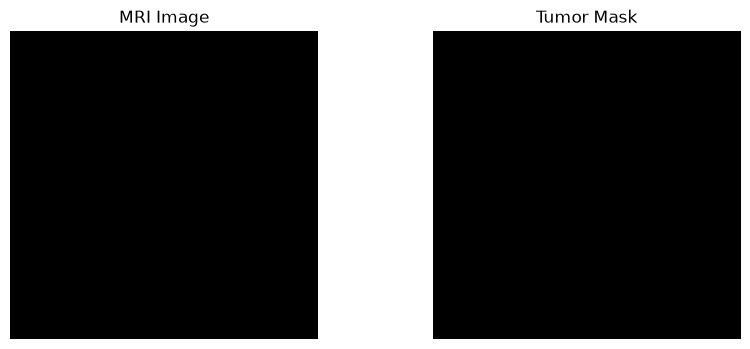

In [3]:
import matplotlib.pyplot as plt

# Get one image and mask from dataset
image, mask = dataset[0]

# Convert image from [4, 240, 240] to [240, 240, 4]
image = image.permute(1, 2, 0)

# Display first channel
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image[:, :, 0], cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

In [4]:
print("Image min:", image.min().item())
print("Image max:", image.max().item())

print("Mask min:", mask.min().item())
print("Mask max:", mask.max().item())

Image min: 0.0
Image max: 0.0
Mask min: 0.0
Mask max: 0.0


In [5]:
image, mask = dataset[75]

print("Image min:", image.min().item())
print("Image max:", image.max().item())

print("Mask min:", mask.min().item())
print("Mask max:", mask.max().item())

Image min: 0.0
Image max: 0.994205892086029
Mask min: 0.0
Mask max: 3.0


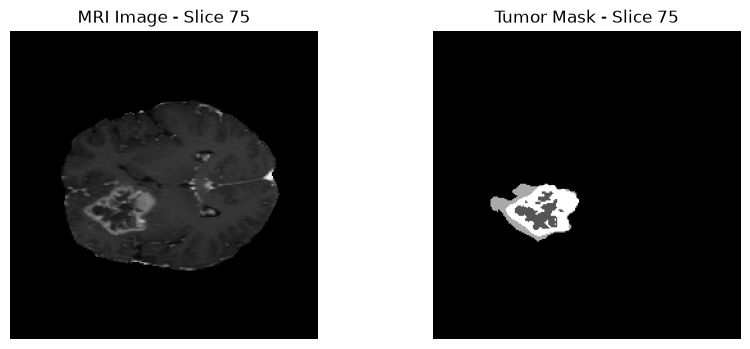

In [6]:
import matplotlib.pyplot as plt

image_display = image.permute(1, 2, 0)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_display[:, :, 0], cmap="gray")
plt.title("MRI Image - Slice 75")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask - Slice 75")
plt.axis("off")

plt.show()

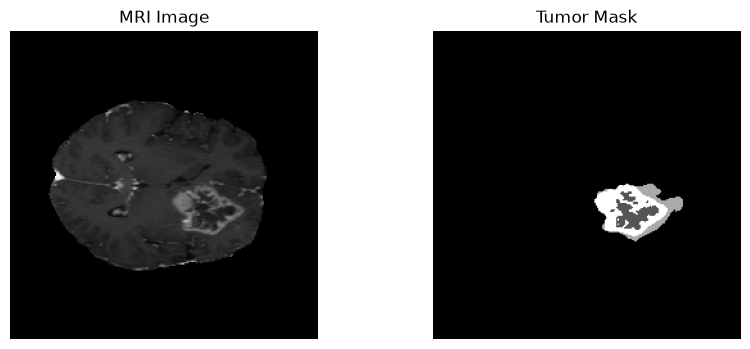

In [7]:
import matplotlib.pyplot as plt

image, mask = dataset[75]

image_display = image.permute(1, 2, 0)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_display[:, :, 0], cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

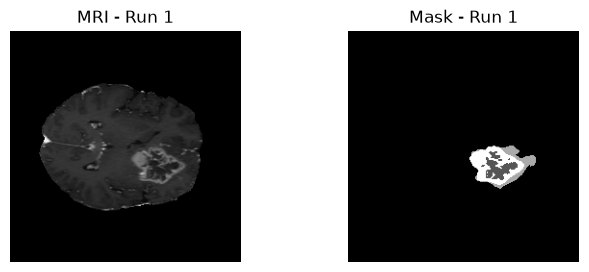

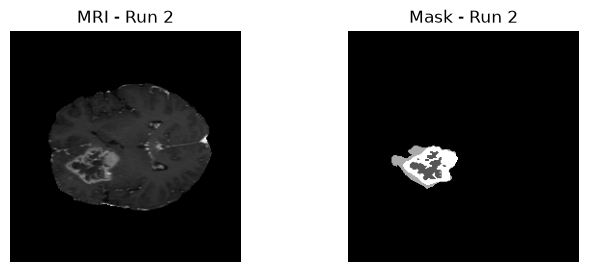

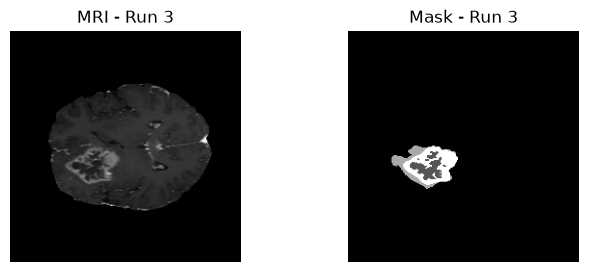

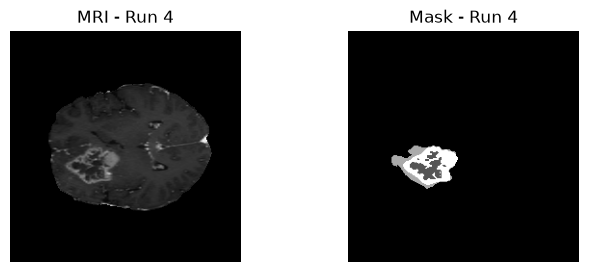

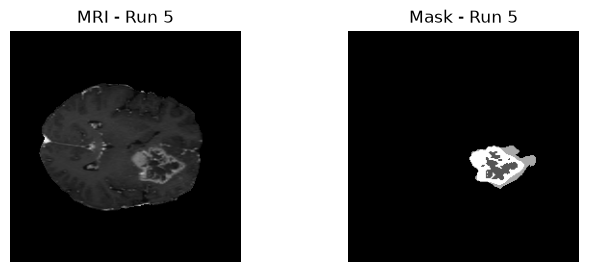

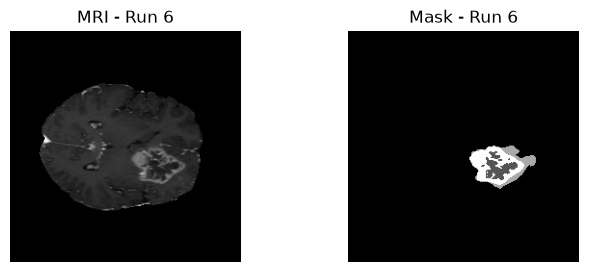

In [8]:
import matplotlib.pyplot as plt

for i in range(6):

    image, mask = dataset[75]

    image_display = image.permute(1, 2, 0)

    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(image_display[:, :, 0], cmap="gray")
    plt.title(f"MRI - Run {i+1}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask - Run {i+1}")
    plt.axis("off")

    plt.show()